In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1') 

In [8]:
print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [9]:
print(df.tail())

                      Name    Year Duration          Genre  Rating Votes  \
15504  Zulm Ko Jala Doonga  (1988)      NaN         Action     4.6    11   
15505                Zulmi  (1999)  129 min  Action, Drama     4.5   655   
15506            Zulmi Raj  (2005)      NaN         Action     NaN   NaN   
15507        Zulmi Shikari  (1988)      NaN         Action     NaN   NaN   
15508         Zulm-O-Sitam  (1998)  130 min  Action, Drama     6.2    20   

            Director           Actor 1         Actor 2        Actor 3  
15504  Mahendra Shah  Naseeruddin Shah   Sumeet Saigal  Suparna Anand  
15505     Kuku Kohli      Akshay Kumar  Twinkle Khanna    Aruna Irani  
15506     Kiran Thej   Sangeeta Tiwari             NaN            NaN  
15507            NaN               NaN             NaN            NaN  
15508   K.C. Bokadia        Dharmendra      Jaya Prada    Arjun Sarja  


In [10]:
print(df.shape)

(15509, 10)


In [11]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [13]:
print(df.describe())

            Rating
count  7919.000000
mean      5.841621
std       1.381777
min       1.100000
25%       4.900000
50%       6.000000
75%       6.800000
max      10.000000


In [14]:
print(df.dtypes)

Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


In [15]:
print(df.isnull().sum().sum())

33523


In [16]:
df.columns = df.columns.str.strip()

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.dropna(inplace=True)

In [19]:
print(df.shape)

(5659, 10)


In [20]:
print(df.isnull().sum())

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


In [21]:
df['Year'] = df['Year'].str.extract('(\d+)')

In [22]:
df['Year'] = pd.to_numeric(df['Year'])

In [23]:
df['Duration'] = df['Duration'].str.replace(' min','')

In [24]:
df['Duration'] = pd.to_numeric(df['Duration'])

In [25]:
print(df[['Year','Duration']].head())

   Year  Duration
1  2019       109
3  2019       110
5  1997       147
6  2005       142
8  2012        82


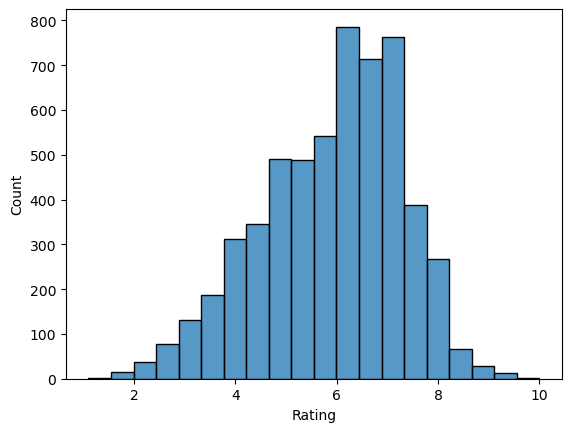

In [26]:
sns.histplot(df['Rating'], bins=20)
plt.show()

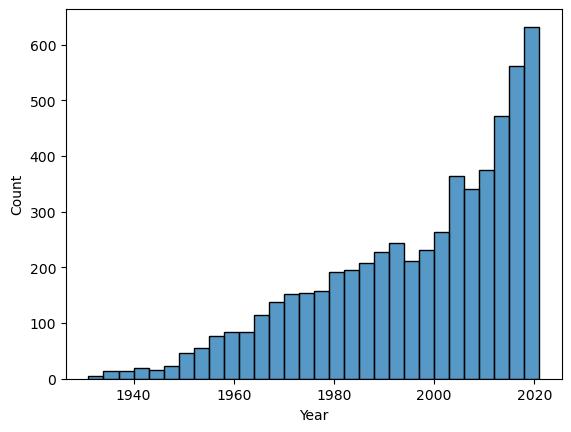

In [27]:
sns.histplot(df['Year'], bins=30)
plt.show()

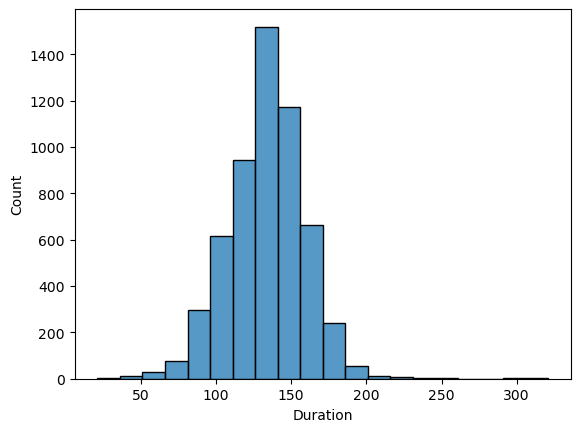

In [28]:
sns.histplot(df['Duration'], bins=20)
plt.show()

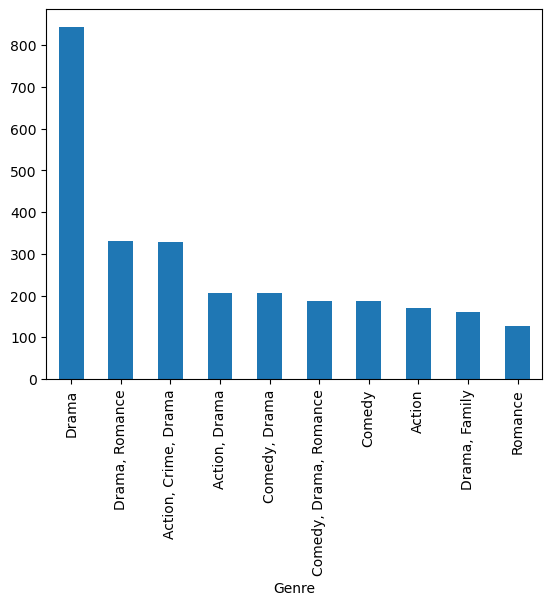

In [29]:
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.show()

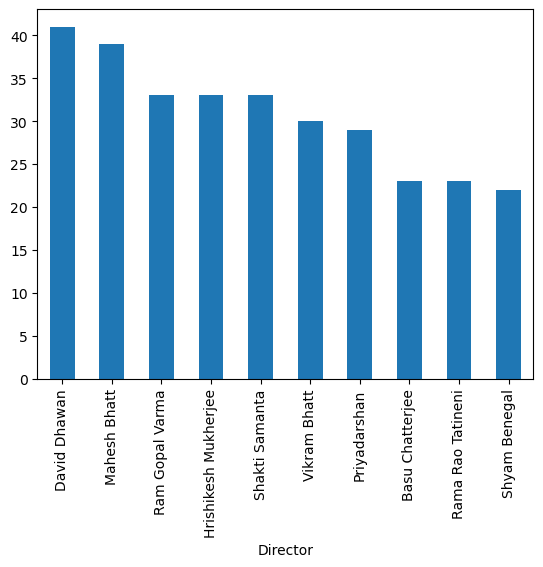

In [30]:
df['Director'].value_counts().head(10).plot(kind='bar')
plt.show()

In [31]:
num_df = df.select_dtypes(include=np.number)

In [32]:
print(num_df.corr())

              Year  Duration    Rating
Year      1.000000 -0.327567 -0.204642
Duration -0.327567  1.000000  0.001839
Rating   -0.204642  0.001839  1.000000


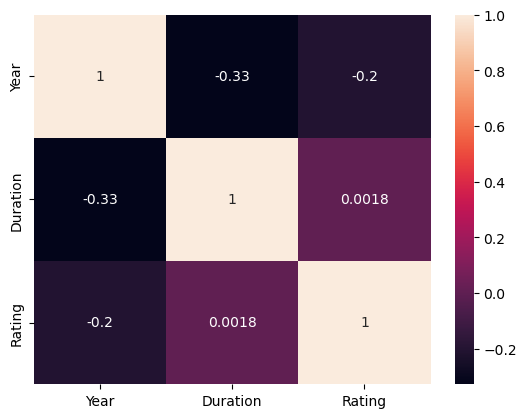

In [33]:
sns.heatmap(num_df.corr(), annot=True)
plt.show()

In [34]:
genre_encoder = LabelEncoder()
df['Genre'] = genre_encoder.fit_transform(df['Genre'])

In [35]:
director_encoder = LabelEncoder()
df['Director'] = director_encoder.fit_transform(df['Director'])

In [36]:
actor1_encoder = LabelEncoder()
actor2_encoder = LabelEncoder()
actor3_encoder = LabelEncoder()

df['Actor 1'] = actor1_encoder.fit_transform(df['Actor 1'])
df['Actor 2'] = actor2_encoder.fit_transform(df['Actor 2'])
df['Actor 3'] = actor3_encoder.fit_transform(df['Actor 3'])

In [37]:
X = df[['Year','Duration','Genre',
        'Director','Actor 1',
        'Actor 2','Actor 3']]

y = df['Rating']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [40]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.9848255300353357
RMSE : 1.254655236368399
R2 Score : 0.14990405640893567


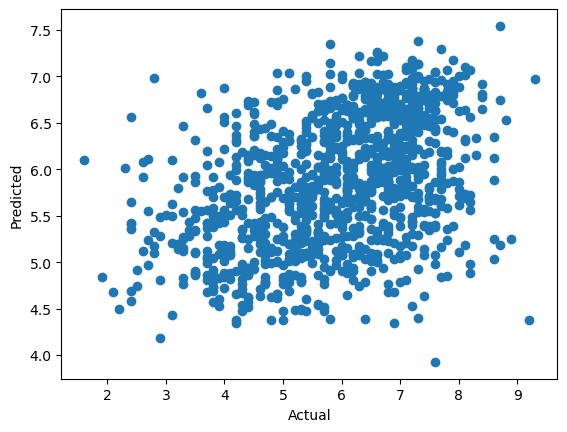

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [43]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(
    by='Importance',
    ascending=False
))

    Feature  Importance
0      Year    0.209346
2     Genre    0.163336
1  Duration    0.130506
4   Actor 1    0.128868
3  Director    0.125422
5   Actor 2    0.122916
6   Actor 3    0.119607


In [44]:
import joblib

joblib.dump(model, "movie_rating_model.pkl")

['movie_rating_model.pkl']

In [45]:
model = joblib.load("movie_rating_model.pkl")

In [53]:
import pandas as pd

sample = pd.DataFrame({
    'Year': [2024],
    'Duration': [120],
    'Genre': [5],
    'Director': [100],
    'Actor 1': [200],
    'Actor 2': [150],
    'Actor 3': [80]
})

rating = model.predict(sample)

print("Predicted Rating:", rating[0])

Predicted Rating: 4.9975


In [54]:
X = df[['Year','Duration','Genre',
        'Director','Actor 1',
        'Actor 2','Actor 3']]

In [55]:
sample = pd.DataFrame(
    [[2024,120,5,100,200,150,80]],
    columns=X.columns
)

rating = model.predict(sample)

print("Predicted Rating:", rating[0])

Predicted Rating: 4.9975
